In [5]:
import pandas as pd


In [6]:
df1=pd.read_csv('deliveries.csv')
df1

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150455,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
150456,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,0,0,0,CJ Jordan,run out,NV Ojha
150457,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,B Kumar,0,...,0,1,0,0,0,1,1,NaN,NaN,NaN
150458,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,B Kumar,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN


<Axes: xlabel='dismissal_kind'>

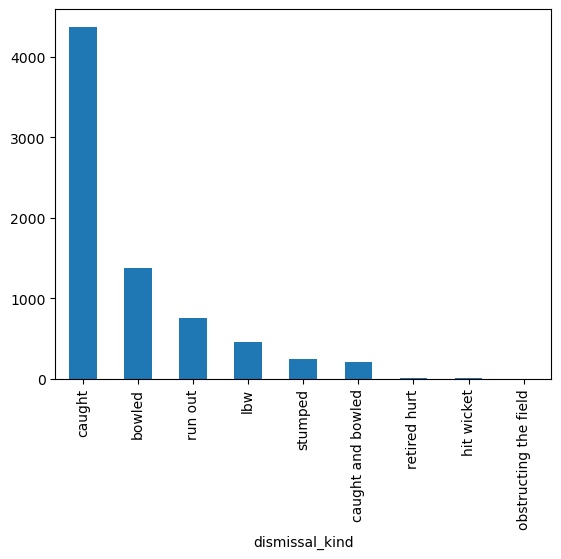

In [13]:
df1['dismissal_kind'].value_counts().plot(kind='bar')

##### Extras by team

<Axes: xlabel='bowling_team'>

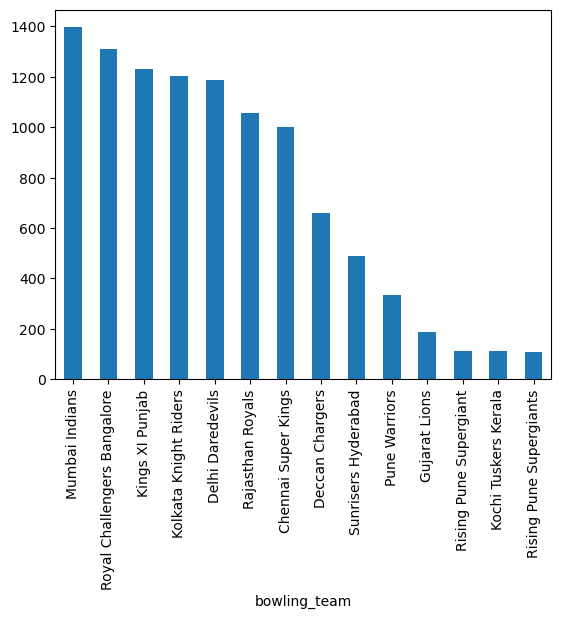

In [14]:
df1.groupby('bowling_team')['extra_runs'].sum().sort_values(ascending=False).plot(kind='bar')

<Axes: ylabel='Frequency'>

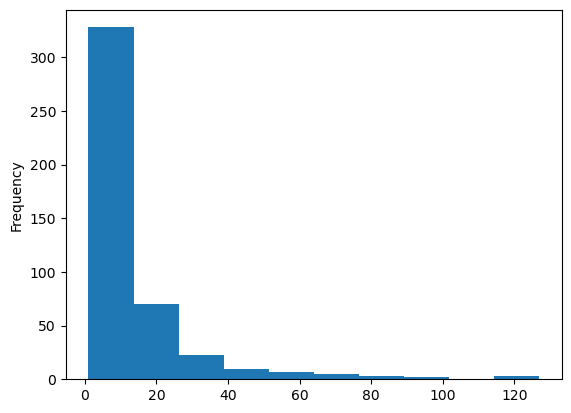

In [20]:
df1.groupby('fielder').size().plot(kind='hist')

<Axes: xlabel='batting_team'>

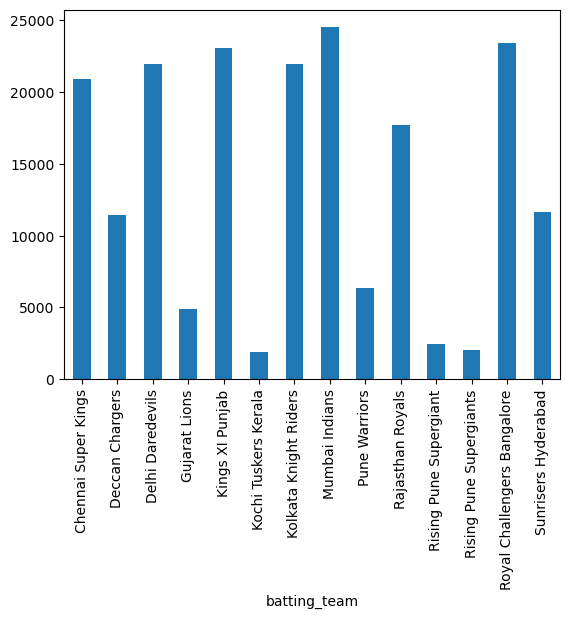

In [18]:
df1.groupby('batting_team')['total_runs'].sum().plot(kind='bar')

In [23]:
runs_scored=df1.groupby('batsman')['batsman_runs'].sum()
runs_scored

batsman
A Ashish Reddy     280
A Chandila           4
A Chopra            53
A Choudhary         25
A Flintoff          62
                  ... 
YV Takawale        192
Yashpal Singh       47
Younis Khan          3
Yuvraj Singh      2591
Z Khan             117
Name: batsman_runs, Length: 461, dtype: int64

In [24]:
balls_faced=df1[df1['wide_runs']==0].groupby('batsman')['total_runs'].size()

In [27]:
strike_rate=(runs_scored/balls_faced)*100
strike_rate

batsman
A Ashish Reddy    145.077720
A Chandila         57.142857
A Chopra           74.647887
A Choudhary       125.000000
A Flintoff        116.981132
                     ...    
YV Takawale       107.865169
Yashpal Singh      71.212121
Younis Khan        42.857143
Yuvraj Singh      131.256332
Z Khan             82.978723
Length: 461, dtype: float64

In [35]:
mask=(strike_rate>140) & (runs_scored>1000)

In [36]:
runs_scored[mask]

batsman
AB de Villiers    3486
CH Gayle          3651
DA Miller         1563
DA Warner         4014
GJ Maxwell        1229
KA Pollard        2354
V Sehwag          2728
YK Pathan         2922
Name: batsman_runs, dtype: int64

In [9]:
legal_balls=df1[(df1['wide_runs']==0) & (df1['noball_runs']==0)]

In [11]:
overs_bowled=legal_balls.groupby('bowler')['

ValueError: Boolean array expected for the condition, not object